# CatBoost YetiRank Reranker (GPU + Optuna + F0.5 Calibration + ROC Curves)
Optimized for Precision-heavy Metric (F0.5) with Singleton Handling.

This notebook preserves the query/group logic (no random row mixing).


### 1. Imports and Configuration
Loading necessary libraries and setting static parameters (GPU, Number of Trials, Validation split).


In [1]:
import os, gc, time, json, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import warnings

# Suppress all future and runtime warnings globally
warnings.filterwarnings('ignore')


try:
    import optuna
except ImportError:
    os.system("pip install -q optuna")
    import optuna

try:
    from tqdm.auto import tqdm
except ImportError:
    os.system("pip install -q tqdm")
    from tqdm.auto import tqdm

import joblib

DATA_PATH = Path('/kaggle/input/datasets/vinaysingh120221/training-data-01/training_features_full.csv')
OUTPUT_DIR = Path('/kaggle/working/catboost_ranker')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
VALIDATION_FRACTION = 0.2
N_TRIALS = 20
USE_GPU = True


### 2. Loading Data
Loads the processed pairwise features directly generated from ANN extraction.


In [2]:
print("[INFO] Loading data in chunks to save RAM...")
chunk_size = 1000000  # 1 million rows at a time
chunks = []

for chunk in pd.read_csv(DATA_PATH, dtype={"query_id": str, "candidate_id": str}, chunksize=chunk_size):
    chunk['label'] = chunk['label'].astype(np.int8)
    feature_cols = [c for c in chunk.columns if c not in ['query_id', 'candidate_id', 'label']]
    for c in feature_cols:
        chunk[c] = pd.to_numeric(chunk[c], errors='coerce').fillna(0.0).astype(np.float32)
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

FEATURE_COLUMNS = feature_cols
print(f"Shape: {df.shape} | Features: {len(FEATURE_COLUMNS)}")
print(f"Total RAM usage of dataframe: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")


[INFO] Loading data in chunks to save RAM...
Shape: (1048575, 36) | Features: 33
Total RAM usage of dataframe: 0.27 GB


### 3. Query Partitioned Split
Very Important: We split by `query_id` ensuring a Source-1 and all its candidates go exactly into train OR val, never mixed!


In [3]:
def query_partitioned_split(dataset_df, val_fraction=0.2, random_state=42):
    unique_queries = np.array(sorted(dataset_df["query_id"].unique()))
    rng = np.random.default_rng(random_state)
    rng.shuffle(unique_queries)
    val_size = max(1, int(len(unique_queries) * val_fraction))
    val_query_set = set(unique_queries[:val_size])
    
    train_df = dataset_df[~dataset_df["query_id"].isin(val_query_set)].copy()
    val_df = dataset_df[dataset_df["query_id"].isin(val_query_set)].copy()
    
    train_df = train_df.sort_values("query_id").reset_index(drop=True)
    val_df = val_df.sort_values("query_id").reset_index(drop=True)
    return train_df, val_df

train_df, val_df = query_partitioned_split(df, val_fraction=VALIDATION_FRACTION, random_state=RANDOM_STATE)
X_train, y_train = train_df[FEATURE_COLUMNS], train_df["label"].to_numpy(dtype=np.int32)
X_val, y_val = val_df[FEATURE_COLUMNS], val_df["label"].to_numpy(dtype=np.int32)


### 4. Custom Metrics & Threshold Tuner
Here we define exactly how F0.5 is calculated, treating singletons rigorously. We also do exhaustive threshold sweep to find the absolute best F0.5 cutoff point, never assuming 0.5!


In [4]:
# Pre-compute Ground Truth Dicts for Evaluation
val_y_true_by_query = val_df[val_df['label'] == 1].groupby('query_id')['candidate_id'].apply(set).to_dict()
val_all_queries = set(val_df['query_id'].unique())

def macro_f05(y_true_by_query, pred_by_query, all_queries):
    scores = []
    # Using a fast list comprehension for the loop
    for qid in all_queries:
        true_set = y_true_by_query.get(qid, set())
        pred_set = pred_by_query.get(qid, set()) # Already a set now
        if not true_set:
            scores.append(1.0 if not pred_set else 0.0)
        else:
            tp = len(true_set & pred_set)
            precision = tp / len(pred_set) if pred_set else 0.0
            recall = tp / len(true_set)
            if precision == 0 and recall == 0:
                scores.append(0.0)
            else:
                scores.append((1.25 * precision * recall) / (0.25 * precision + recall))
    return np.mean(scores)

def exhaustive_threshold_search(val_preds_df, fast_mode=False):
    print("[INFO] Running Exhaustive Threshold Sweep...")
    val_preds_df = val_preds_df.sort_values(["query_id", "score"], ascending=[True, False])
    val_preds_df['rank'] = val_preds_df.groupby('query_id').cumcount() + 1
    val_preds_df['top_score'] = val_preds_df.groupby('query_id')['score'].transform('max')
    
    best_f05 = -1
    best_config = {}
    
    # Pre-extract numpy arrays for blazing fast dictionary creation (Pandas groupby is too slow)
    from collections import defaultdict
    qids = val_preds_df['query_id'].values
    cids = val_preds_df['candidate_id'].values
    scores = val_preds_df['score'].values
    top_scores = val_preds_df['top_score'].values
    ranks = val_preds_df['rank'].values
    
    margin_sweep = [0.0, 0.5, 1.0] if fast_mode else np.arange(0.0, 5.0, 0.1)
    for margin in tqdm(margin_sweep, desc="Margin Sweep", disable=fast_mode):
        mask = scores >= (top_scores - margin)
        
        pred_dict = defaultdict(set)
        for q, c in zip(qids[mask], cids[mask]):
            pred_dict[q].add(c)
            
        score = macro_f05(val_y_true_by_query, pred_dict, val_all_queries)
        if score > best_f05: 
            best_f05 = score; best_config = {'type': 'margin', 'margin': margin}
            
    unique_scores = np.sort(val_preds_df['score'].unique())[::-1]
    pct_count = 20 if fast_mode else 100
    test_thresh = np.percentile(unique_scores, np.linspace(0, 100, pct_count))
    k_list = [5, 10] if fast_mode else [1, 2, 3, 5, 10, 20]
    
    for t in tqdm(test_thresh, desc="Global Sweep", disable=fast_mode):
        for k in k_list:
            mask = (scores >= t) & (ranks <= k)
            
            pred_dict = defaultdict(set)
            for q, c in zip(qids[mask], cids[mask]):
                pred_dict[q].add(c)
                
            score = macro_f05(val_y_true_by_query, pred_dict, val_all_queries)
            if score > best_f05:
                best_f05 = score; best_config = {'type': 'global_k', 'threshold': t, 'max_k': k}
                
    return best_f05, best_config


### 5. Hyperparameter Tuning (Optuna)
We tune depth, learning rate, leaf count, regularization etc. The objective explicitly evaluates `macro_f05` after applying a fast threshold calibration.


In [5]:
try:
    from catboost import CatBoostRanker, Pool
except ImportError:
    os.system("pip install -q catboost")
    from catboost import CatBoostRanker, Pool

print("[INFO] Tuning CatBoost YetiRank...")

train_qids = pd.factorize(train_df['query_id'])[0]
val_qids = pd.factorize(val_df['query_id'])[0]

train_pool = Pool(data=X_train, label=y_train, group_id=train_qids)
val_pool = Pool(data=X_val, label=y_val, group_id=val_qids)

def objective(trial):
    params = {
        "loss_function": "YetiRank",
        "custom_metric": ["NDCG"],
        "task_type": "GPU" if USE_GPU else "CPU",
        "iterations": 500,
        "learning_rate": trial.suggest_categorical("learning_rate", [0.02, 0.05, 0.1]),
        "depth": trial.suggest_categorical("depth", [4, 6, 8]),
        "l2_leaf_reg": trial.suggest_categorical("l2_leaf_reg", [1, 3, 5]),
        "random_strength": trial.suggest_categorical("random_strength", [0.1, 1, 10]),
        "border_count": 128,
        "random_seed": RANDOM_STATE,
        "verbose": 0,
        "early_stopping_rounds": 30
    }
    
    ranker = CatBoostRanker(**params)
    ranker.fit(train_pool, eval_set=val_pool)
    
    val_preds = val_df[['query_id', 'candidate_id', 'label']].copy()
    val_preds['score'] = ranker.predict(val_pool)
    best_f05, _ = exhaustive_threshold_search(val_preds, fast_mode=True)
    return best_f05

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f"\n🏆 Best Macro F0.5: {study.best_value:.5f}")
print(f"🏆 Best Params: {study.best_params}")


[INFO] Tuning CatBoost YetiRank...


[I 2026-09-28 23:26:54,359] A new study created in memory with name: no-name-c0280d0f-a73e-45fc-83ab-a0182a767964


  0%|          | 0/20 [00:00<?, ?it/s]

Default metric period is 5 because PFound, NDCG is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


[INFO] Running Exhaustive Threshold Sweep...
[I 2026-09-28 23:27:11,936] Trial 0 finished with value: 0.9269633508440386 and parameters: {'learning_rate': 0.05, 'depth': 6, 'l2_leaf_reg': 3, 'random_strength': 1}. Best is trial 0 with value: 0.9269633508440386.


...

[INFO] Running Exhaustive Threshold Sweep...
[I 2026-09-28 23:30:55,376] Trial 17 finished with value: 0.9336519597689857 and parameters: {'learning_rate': 0.1, 'depth': 8, 'l2_leaf_reg': 1, 'random_strength': 10}. Best is trial 15 with value: 0.9351501138486847.


Default metric period is 5 because PFound, NDCG is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


[INFO] Running Exhaustive Threshold Sweep...
[I 2026-09-28 23:31:12,038] Trial 18 finished with value: 0.9195011638198376 and parameters: {'learning_rate': 0.02, 'depth': 8, 'l2_leaf_reg': 1, 'random_strength': 10}. Best is trial 15 with value: 0.9351501138486847.


Default metric period is 5 because PFound, NDCG is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


[INFO] Running Exhaustive Threshold Sweep...
[I 2026-09-28 23:31:24,652] Trial 19 finished with value: 0.9341763697179349 and parameters: {'learning_rate': 0.1, 'depth': 8, 'l2_leaf_reg': 1, 'random_strength': 10}. Best is trial 15 with value: 0.9351501138486847.

🏆 Best Macro F0.5: 0.93515
🏆 Best Params: {'learning_rate': 0.1, 'depth': 8, 'l2_leaf_reg': 1, 'random_strength': 0.1}


### 6. Retrain Best Model & Extract Matches
Using the best parameters found by Optuna, we train for longer iterations, explicitly save the model `.txt`/`.cbm` weights, do a deep threshold sweep, and save all artifacts (`model.joblib`, `predictions.csv`).


In [6]:
# === RETRAIN BEST MODEL ===
best_params = study.best_params
best_params.update({"loss_function": "YetiRank", "custom_metric": ["NDCG"], "task_type": "GPU" if USE_GPU else "CPU", "iterations": 1000, "random_seed": RANDOM_STATE, "verbose": 100})

print("[INFO] Retraining final model with best params on GPU...")
final_ranker = CatBoostRanker(**best_params)
final_ranker.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50)

weights_path = OUTPUT_DIR / "catboost_weights.cbm"
final_ranker.save_model(str(weights_path))
print(f"\n[SUCCESS] Model Weights successfully saved to: {weights_path}\n")

val_preds = val_df[['query_id', 'candidate_id', 'label']].copy()
val_preds['score'] = final_ranker.predict(val_pool)
final_f05, final_thresh_config = exhaustive_threshold_search(val_preds, fast_mode=False)

print("\n" + "="*60)
print("FINAL OPTIMIZED PIPELINE")
print("="*60)
print(f"Macro F0.5    : {final_f05:.6f}")
print(f"Threshold Strategy : {final_thresh_config}")

val_preds.to_csv(OUTPUT_DIR / "validation_predictions.csv", index=False)
model_path = OUTPUT_DIR / "model.joblib"
joblib.dump({"model": final_ranker, "features": FEATURE_COLUMNS, "threshold": final_thresh_config, "val_macro_f05": final_f05}, model_path)
print(f"[SUCCESS] Full Pipeline Saved to {model_path}")


[INFO] Retraining final model with best params on GPU...


Default metric period is 5 because PFound, NDCG is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	test: 0.9389294	best: 0.9389294 (0)	total: 58.9ms	remaining: 58.8s
100:	test: 0.9408701	best: 0.9408701 (100)	total: 2.7s	remaining: 24s
200:	test: 0.9410134	best: 0.9410195 (193)	total: 5.19s	remaining: 20.6s
300:	test: 0.9410755	best: 0.9410860 (260)	total: 7.7s	remaining: 17.9s
bestTest = 0.9410859592
bestIteration = 260
Shrink model to first 261 iterations.

[SUCCESS] Model Weights successfully saved to: /kaggle/working/catboost_ranker/catboost_weights.cbm

[INFO] Running Exhaustive Threshold Sweep...


Margin Sweep:   0%|          | 0/50 [00:00<?, ?it/s]

Global Sweep:   0%|          | 0/100 [00:00<?, ?it/s]


FINAL OPTIMIZED PIPELINE
Macro F0.5    : 0.935660
Threshold Strategy : {'type': 'global_k', 'threshold': np.float64(0.5418135948212635), 'max_k': 10}
[SUCCESS] Full Pipeline Saved to /kaggle/working/catboost_ranker/model.joblib


### 7. Evaluation Visuals
Plots standard ROC-AUC and Precision-Recall Curves based on our validated scores vs ground truth.


[INFO] Generating ROC and Precision-Recall Curves...


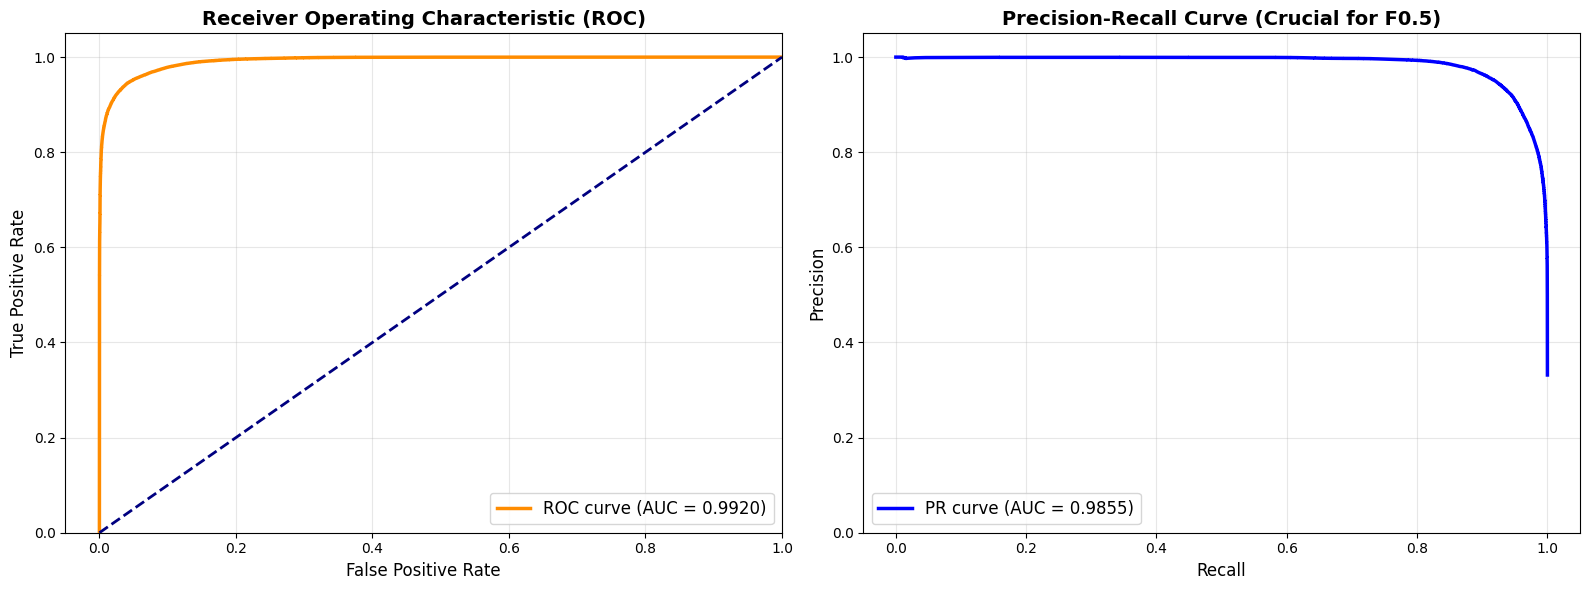


[SUMMARY] Area Under ROC Curve (AUC) : 0.9920
[SUMMARY] Area Under PR Curve (AUC)  : 0.9855


In [7]:
print("[INFO] Generating ROC and Precision-Recall Curves...")
y_true = val_preds['label'].values
y_scores = val_preds['score'].values

fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores)
pr_auc = auc(recall, precision)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlim([-0.05, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right", fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.plot(recall, precision, color='blue', lw=2.5, label=f'PR curve (AUC = {pr_auc:.4f})')
ax2.set_xlim([-0.05, 1.05])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve (Crucial for F0.5)', fontsize=14, fontweight='bold')
ax2.legend(loc="lower left", fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_pr_curves.png")
plt.show()

print(f"\n[SUMMARY] Area Under ROC Curve (AUC) : {roc_auc:.4f}")
print(f"[SUMMARY] Area Under PR Curve (AUC)  : {pr_auc:.4f}")
